<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Batch scoring and credit-limit management

*Draft notebook — a narrative layer over the tested `src/steps` code, not a re-implementation. In the pipeline these steps hand CSVs through S3 (`eligible.csv → scores.csv → decisions.csv`) and run as SageMaker Processing jobs; here they run in-memory on the local portfolio so the decisions are visible inline.*

*Batch has no endpoint — it's a Pipeline — so the **`MODE`** parameter changes the **data source**: `local` reads the CSV, `aws` reads the portfolio from the deployed Redshift warehouse (the Data API). The score/decide logic is identical either way.*

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters</h2>

Tagged `parameters`: `papermill batch_scoring.ipynb out.ipynb -p MODE aws` (needs the warehouse up: `make -C aws deploy seed`).

In [1]:
# parameters
MODE = "local"  # "local": read the CSV  |  "aws": read the portfolio from Redshift
REGION = "us-east-1"
WORKGROUP = (
    "portfolio-wg"  # the Redshift Serverless workgroup (stack output WorkgroupName)
)
DATABASE = "portfolio"

In [2]:
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

# import the SAME tested step logic the pipeline runs
sys.path.insert(0, "../src/steps")

if MODE == "local":
    portfolio = pd.read_csv("../data/portfolio.csv")
else:
    import time

    import boto3

    _data = boto3.client("redshift-data", region_name=REGION)
    _q = _data.execute_statement(
        WorkgroupName=WORKGROUP, Database=DATABASE, Sql="SELECT * FROM customers"
    )
    while _data.describe_statement(Id=_q["Id"])["Status"] not in (
        "FINISHED",
        "FAILED",
        "ABORTED",
    ):
        time.sleep(1)
    _r = _data.get_statement_result(Id=_q["Id"])
    _cols = [c["name"] for c in _r["ColumnMetadata"]]
    _rows = [[next(iter(cell.values())) for cell in row] for row in _r["Records"]]
    portfolio = pd.DataFrame(_rows, columns=_cols)

with open("../data/feature_spec.json") as f:
    features = json.load(f)["features"]
f"[{MODE}] {len(portfolio):,} customers, {portfolio['default_12m'].notna().mean():.0%} labeled"

'[local] 20,000 customers, 88% labeled'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the customer count loaded for this MODE and the share of rows carrying a default label:

```plain
'[local] 20,000 customers, 88% labeled'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-database" style="color:#18ab4b"></i>&nbsp; The portfolio</h2>

In [3]:
portfolio.head()

,customer_id,current_limit,utilization,months_on_book,dpd_30_count_12m,monthly_income,payment_ratio,cash_advance_share,default_12m
0,c-000000,3300.0,0.161,38,1,2206.0,0.705,0.461,0.0
1,c-000001,2200.0,0.305,53,0,1699.0,0.613,0.088,0.0
2,c-000002,1800.0,0.315,93,0,2910.0,0.857,0.009,0.0
3,c-000003,4600.0,0.176,54,0,4065.0,0.820,0.119,0.0
4,c-000004,15700.0,0.416,23,0,5814.0,0.637,0.007,0.0


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the first five customers with their credit limit, utilization, and behavioral features:

```plain
  customer_id  current_limit  utilization  months_on_book  dpd_30_count_12m  \
0    c-000000         3300.0        0.161              38                 1   
1    c-000001         2200.0        0.305              53                 0   
2    c-000002         1800.0        0.315              93                 0   
3    c-000003         4600.0        0.176              54                 0   
4    c-000004        15700.0        0.416              23                 0   

   monthly_income  payment_ratio  cash_advance_share  default_12m  
0          2206.0          0.705               0.461          0.0  
1          1699.0          0.613               0.088          0.0  
2          2910.0          0.857               0.009          0.0  
3          4065.0          0.820               0.119          0.0  
4          5814.0          0.637               0.007          0.0  
```

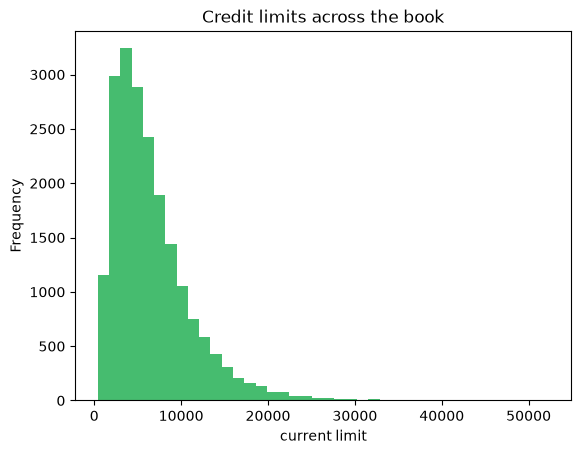

'default rate 1.18%'

In [4]:
ax = portfolio["current_limit"].plot.hist(bins=40, color="#18ab4b", alpha=0.8)
ax.set_xlabel("current limit")
ax.set_title("Credit limits across the book")
plt.show()
f"default rate {portfolio['default_12m'].mean():.2%}"

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the book-wide 12-month default rate, printed under the credit-limit histogram:

```plain
'default rate 1.18%'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-filter" style="color:#18ab4b"></i>&nbsp; Shortlist — who is eligible for a review</h2>

The pipeline runs this as SQL against the warehouse; the same predicate as a frame filter here.

In [5]:
eligible = portfolio.query(
    "months_on_book >= 6 and dpd_30_count_12m <= 2 and utilization > 0.05"
).copy()
f"{len(eligible):,} of {len(portfolio):,} customers eligible for review"

'18,284 of 20,000 customers eligible for review'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** how many customers pass the eligibility filter for a limit review:

```plain
'18,284 of 20,000 customers eligible for review'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-user-graduate" style="color:#18ab4b"></i>&nbsp; Score — the behavior model</h2>

In [6]:
from catboost import CatBoostClassifier

# same fit as src/steps/score.py: labeled history -> P(default) on the eligible book
history = portfolio.dropna(subset=["default_12m"])
model = CatBoostClassifier(iterations=300, random_seed=5, verbose=0)
model.fit(history[features], history["default_12m"].astype(int))

scored = eligible[["customer_id", "current_limit", "utilization"]].copy()
scored["pd_12m"] = model.predict_proba(eligible[features])[:, 1].round(6)
f"scored {len(scored):,} customers, mean pd {scored['pd_12m'].mean():.3f}"

'scored 18,284 customers, mean pd 0.011'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the number of customers scored and their mean predicted 12-month default probability:

```plain
'scored 18,284 customers, mean pd 0.011'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-chart-bar" style="color:#18ab4b"></i>&nbsp; Metrics</h2>

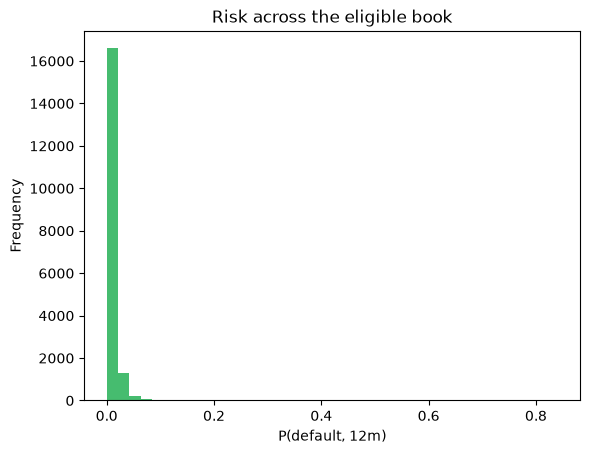

In [7]:
ax = scored["pd_12m"].plot.hist(bins=40, color="#18ab4b", alpha=0.8)
ax.set_xlabel("P(default, 12m)")
ax.set_title("Risk across the eligible book")
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-code-branch" style="color:#18ab4b"></i>&nbsp; Decide — the limit rules</h2>

This imports the **exact** `decide()` from `src/steps/decide.py` — the same function the pipeline's `decide` step runs, no fork.

In [8]:
from decide import decide  # the tested rule, imported not copied

d = scored.apply(decide, axis=1, result_type="expand")
scored["decision"], scored["new_limit"] = d[0], d[1]
scored["decision"].value_counts()

decision
KEEP        14455
INCREASE     3766
DECREASE       63
Name: count, dtype: int64

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the decide() rule's split of the eligible book into KEEP, INCREASE, and DECREASE:

```plain
decision
KEEP        14455
INCREASE     3766
DECREASE       63
Name: count, dtype: int64
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-clipboard-check" style="color:#18ab4b"></i>&nbsp; Impact</h2>

In [9]:
before, after = scored["current_limit"].sum(), scored["new_limit"].sum()
summary = scored.groupby("decision").agg(
    customers=("customer_id", "size"),
    limit_before=("current_limit", "sum"),
    limit_after=("new_limit", "sum"),
)
summary

,customers,limit_before,limit_after
decision,,,
DECREASE,63,496300.0,347410.0
INCREASE,3766,24698800.0,29638560.0
KEEP,14455,94668200.0,94668200.0


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** per-decision customer counts with total credit limit before and after the review:

```plain
          customers  limit_before  limit_after
decision                                      
DECREASE         63      496300.0     347410.0
INCREASE       3766    24698800.0   29638560.0
KEEP          14455    94668200.0   94668200.0
```

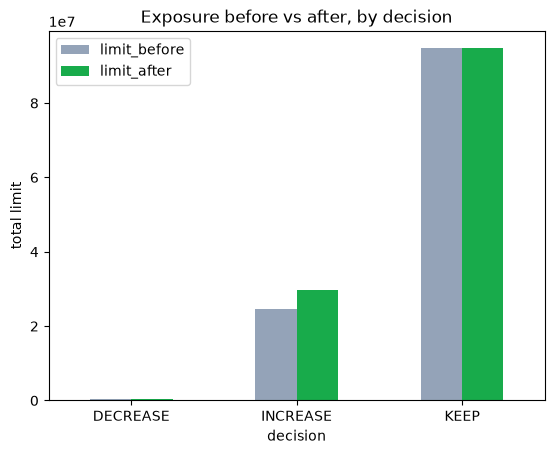

'net exposure change +4,790,870 (+4.0%)'

In [10]:
ax = summary[["limit_before", "limit_after"]].plot.bar(color=["#94a3b8", "#18ab4b"])
ax.set_ylabel("total limit")
ax.set_title("Exposure before vs after, by decision")
plt.xticks(rotation=0)
plt.show()
f"net exposure change {after - before:+,.0f} ({(after / before - 1):+.1%})"

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the net change in total exposure, printed beneath the before/after bar chart:

```plain
'net exposure change +4,790,870 (+4.0%)'
```

---
*On AWS the same four steps run as a SageMaker Pipeline (`PIPELINE_MODE=aws`) against Redshift Serverless — see `aws/README.md`. This notebook is the narrative view of that pipeline's logic.*